# Tesla Deliveries ML Pipeline

End-to-end notebook for preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting on Tesla deliveries data from 2015 to 2025.

Target for the regression workflow: `Estimated_Deliveries`.

The time-series workflow uses monthly aggregated deliveries.

In [18]:
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import cast

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor  # type: ignore[import-not-found]
except ImportError:
    XGBRegressor = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path(r"c:\Users\katur\OneDrive\Desktop\week2_celabal\tesla_deliveries_dataset_2015_2025.csv")
RAW_BACKUP_PATH = DATA_PATH.with_name(f"{DATA_PATH.stem}_raw_backup.csv")
MODEL_DIR = DATA_PATH.parent / "models"

## Step 2: Load the Dataset

This cell loads the CSV, creates a raw backup copy, and prints a quick structural summary.

In [19]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.to_csv(RAW_BACKUP_PATH, index=False)

df = df_raw.copy()

print(f"Loaded dataset: {DATA_PATH.name}")
print(f"Raw backup saved to: {RAW_BACKUP_PATH}")
print("Shape:", df.shape)
print("Null counts:\n", df.isna().sum())
display(df.head())
df.info()

Loaded dataset: tesla_deliveries_dataset_2015_2025.csv
Raw backup saved to: c:\Users\katur\OneDrive\Desktop\week2_celabal\tesla_deliveries_dataset_2015_2025_raw_backup.csv
Shape: (2640, 12)
Null counts:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


## Step 3: Data Preprocessing

Convert types, standardize text fields, handle missing values, and remove duplicates before modeling.

In [20]:
numeric_columns = [
    "Year",
    "Month",
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
]

categorical_columns = ["Region", "Model", "Source_Type"]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    df[column] = df[column].replace({"nan": np.nan, "None": np.nan, "": np.nan})
    df[column] = df[column].str.title()

df["Date"] = pd.to_datetime(
    df["Year"].astype(int).astype(str)
    + "-"
    + df["Month"].astype(int).astype(str).str.zfill(2)
    + "-01",
    errors="coerce",
)

duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().copy()

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode().iloc[0])

assert df["Estimated_Deliveries"].notna().all()
assert df["Date"].notna().all()

print("Duplicate rows removed:", duplicate_count)
print("Shape after preprocessing:", df.shape)
print("Remaining nulls:\n", df.isna().sum())
df = df.sort_values("Date").reset_index(drop=True)
display(df.head())
df.info()

Duplicate rows removed: 0
Shape after preprocessing: (2640, 13)
Remaining nulls:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   str           
 3   Model                 2640 non-null   str           
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   str           
 11  Charging_Stations     2640 non-null   int64         
 12  Date                  2640 non-null   datetime64[us]
dtypes: datetime64[us](1), float64

## Step 4: EDA

Explore distributions, trends, group summaries, correlations, seasonality, and outliers.

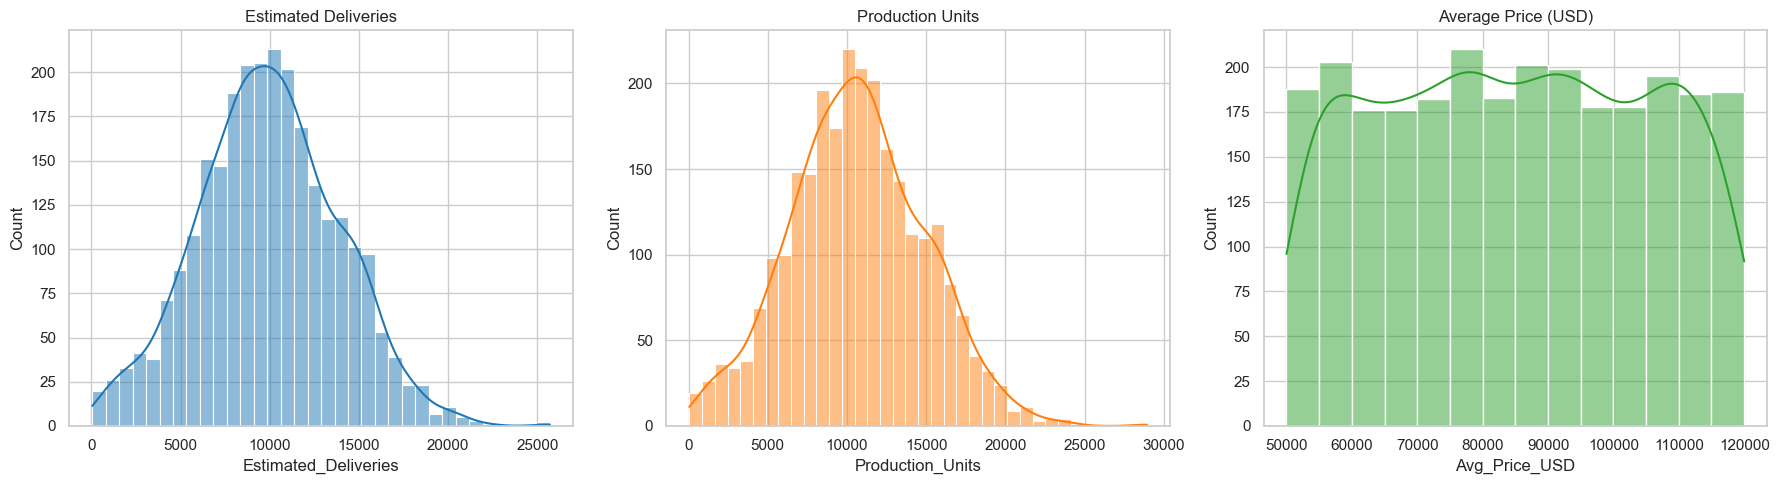

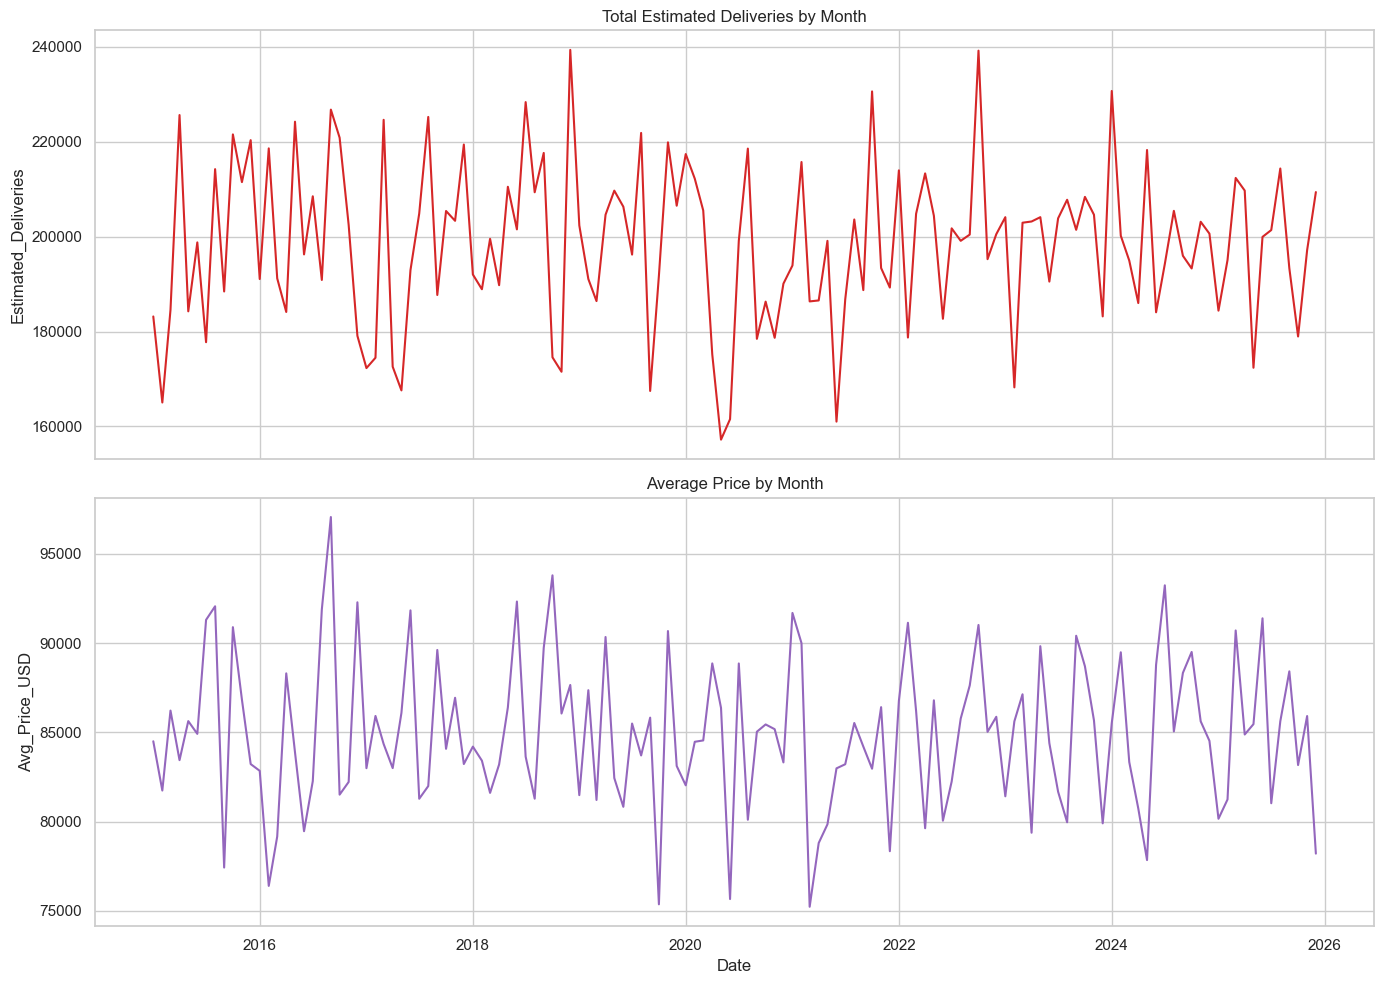

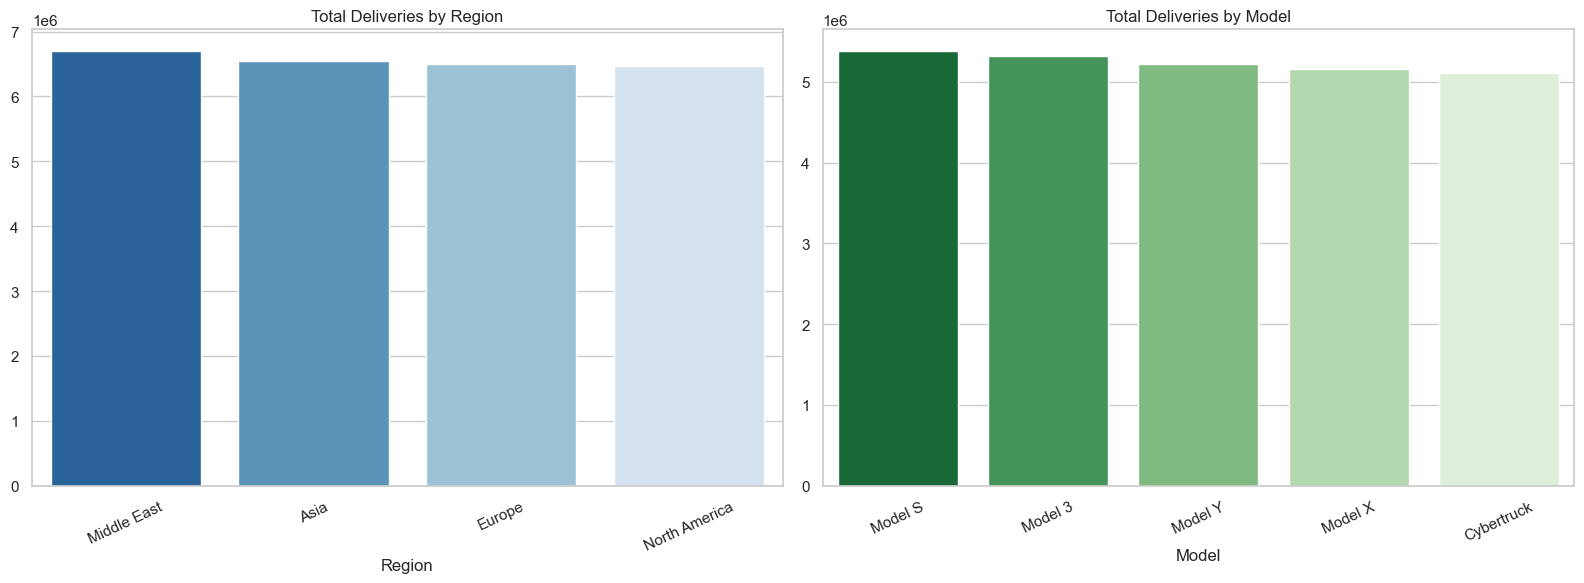

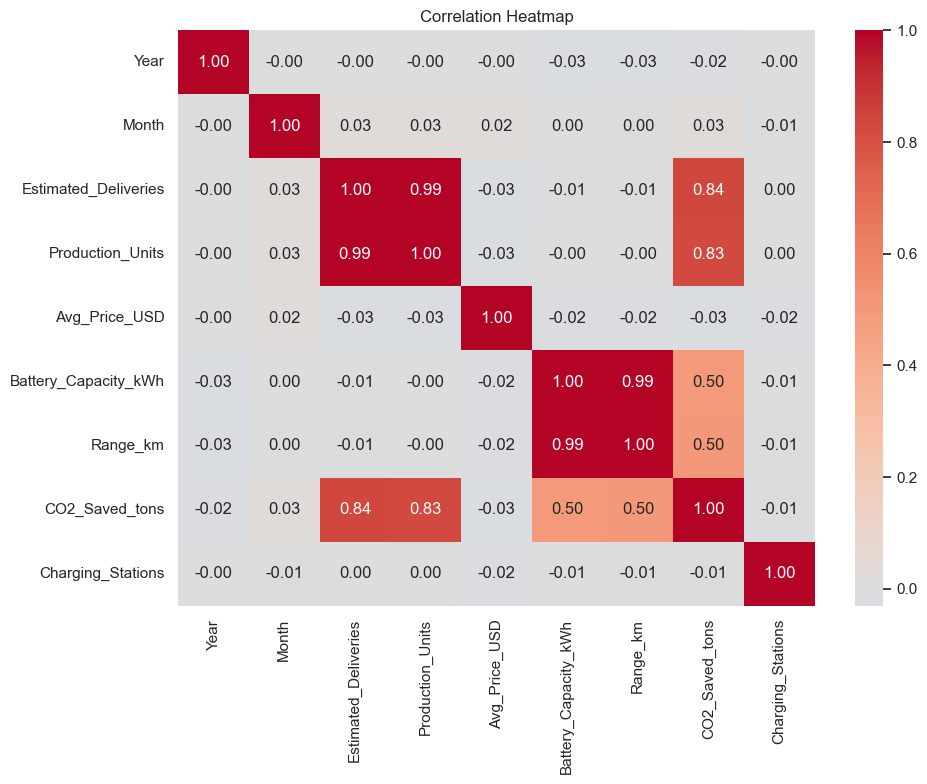

,deliveries_mean,production_mean,avg_price_mean
Year,,,
2015,9896.945833,10607.062500,85684.351167
2016,10142.004167,10904.166667,84776.998500
2017,9793.820833,10529.516667,85111.401667
2018,10096.266667,10826.895833,86111.865917
2019,10017.625000,10723.008333,83990.488833


,deliveries_sum,price_mean
Region,,
Asia,6539935,85161.733773
Europe,6494035,86107.731939
Middle East,6698045,84535.999091
North America,6462592,83823.896515


,deliveries_sum,price_mean
Model,,
Cybertruck,5109779,84498.872159
Model 3,5321919,84528.004223
Model S,5380385,85185.401269
Model X,5157240,84243.212936
Model Y,5225284,86081.211061


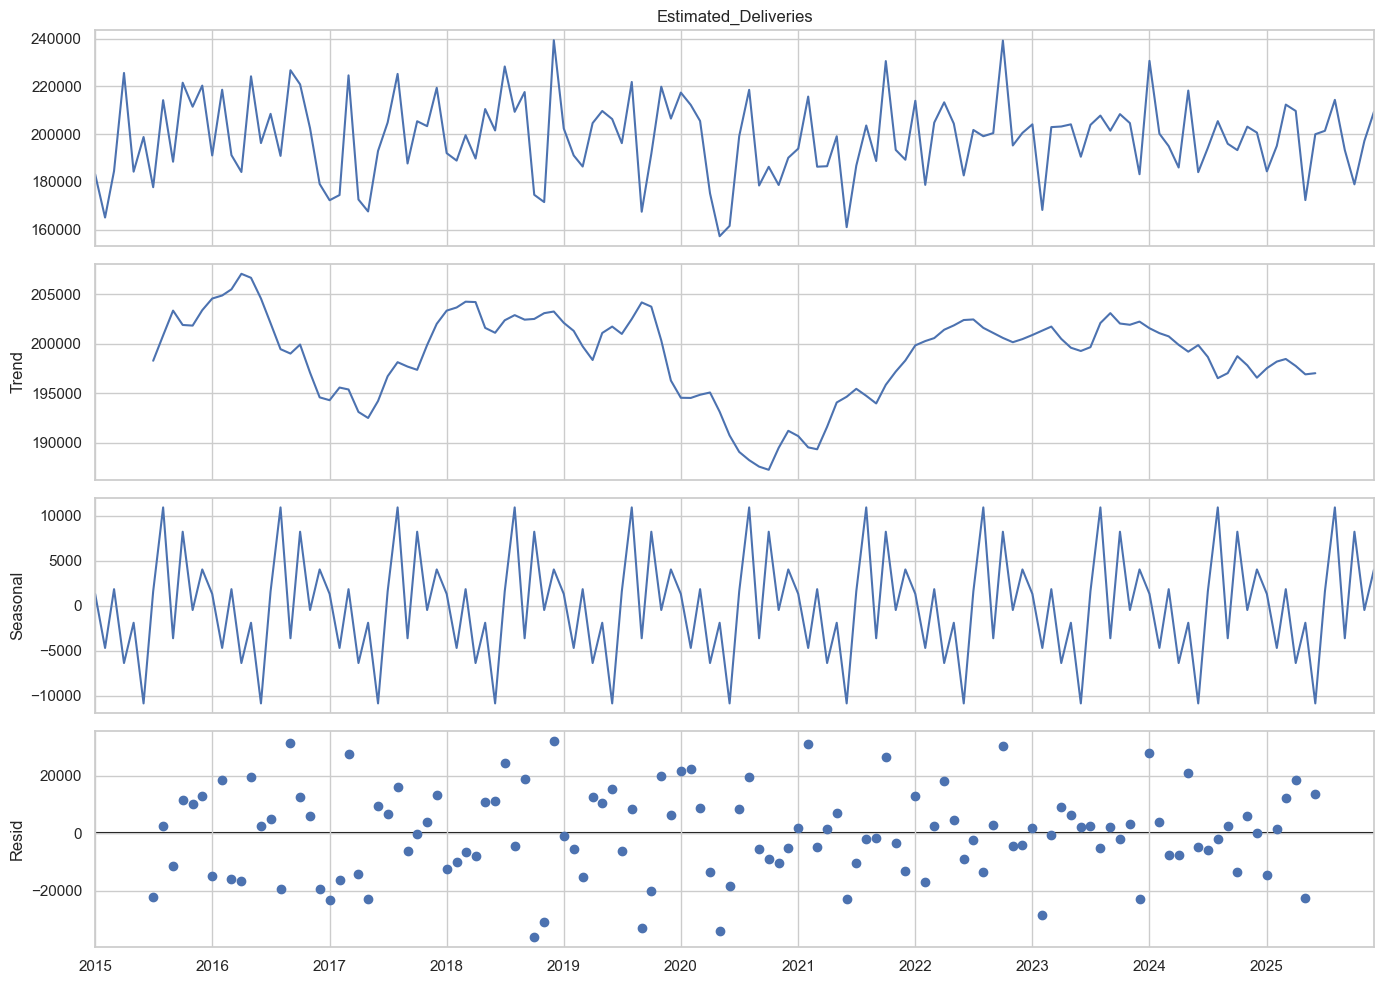

Estimated_Deliveries IQR bounds: -535.38 to 20337.62
Outlier count: 12


,Date,Region,Model,Estimated_Deliveries
58,2015-03-01,Asia,Model 3,25410
115,2015-06-01,Middle East,Model Y,22315
192,2015-10-01,Europe,Model S,20529
419,2016-09-01,Europe,Model S,20358
474,2016-12-01,Asia,Model S,20577


In [21]:
eda_df = df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=eda_df, x="Estimated_Deliveries", kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Estimated Deliveries")
sns.histplot(data=eda_df, x="Production_Units", kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Production Units")
sns.histplot(data=eda_df, x="Avg_Price_USD", kde=True, ax=axes[2], color="#2ca02c")
axes[2].set_title("Average Price (USD)")
plt.tight_layout()
plt.show()

monthly_eda = eda_df.groupby("Date", as_index=False).agg(
    Estimated_Deliveries=("Estimated_Deliveries", "sum"),
    Avg_Price_USD=("Avg_Price_USD", "mean"),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.lineplot(data=monthly_eda, x="Date", y="Estimated_Deliveries", ax=axes[0], color="#d62728")
axes[0].set_title("Total Estimated Deliveries by Month")
sns.lineplot(data=monthly_eda, x="Date", y="Avg_Price_USD", ax=axes[1], color="#9467bd")
axes[1].set_title("Average Price by Month")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
region_summary = eda_df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)
model_summary = eda_df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

sns.barplot(x=region_summary.index, y=region_summary.values, ax=axes[0], palette="Blues_r")
axes[0].set_title("Total Deliveries by Region")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(x=model_summary.index, y=model_summary.values, ax=axes[1], palette="Greens_r")
axes[1].set_title("Total Deliveries by Model")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
correlation_matrix = eda_df[numeric_columns].corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

groupby_year = eda_df.groupby("Year").agg(
    deliveries_mean=("Estimated_Deliveries", "mean"),
    production_mean=("Production_Units", "mean"),
    avg_price_mean=("Avg_Price_USD", "mean"),
)
groupby_region = eda_df.groupby("Region").agg(
    deliveries_sum=("Estimated_Deliveries", "sum"),
    price_mean=("Avg_Price_USD", "mean"),
)
groupby_model = eda_df.groupby("Model").agg(
    deliveries_sum=("Estimated_Deliveries", "sum"),
    price_mean=("Avg_Price_USD", "mean"),
)

display(groupby_year.head())
display(groupby_region)
display(groupby_model)

monthly_series = eda_df.groupby("Date")["Estimated_Deliveries"].sum().asfreq("MS")
monthly_series = monthly_series.interpolate(method="linear")

seasonal_decomposition = seasonal_decompose(monthly_series, model="additive", period=12)
fig = seasonal_decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

q1 = eda_df["Estimated_Deliveries"].quantile(0.25)
q3 = eda_df["Estimated_Deliveries"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_mask = (eda_df["Estimated_Deliveries"] < lower_bound) | (eda_df["Estimated_Deliveries"] > upper_bound)
outlier_count = outlier_mask.sum()

print(f"Estimated_Deliveries IQR bounds: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"Outlier count: {outlier_count}")
display(eda_df.loc[outlier_mask, ["Date", "Region", "Model", "Estimated_Deliveries"]].head())

## Step 5: Feature Engineering

Create time features, lagged signals, ratios, and reusable preprocessing transforms.

In [22]:
feature_df = df.copy().sort_values(["Region", "Model", "Date"]).reset_index(drop=True)
feature_df["Year_Month"] = feature_df["Date"].dt.to_period("M").astype(str)
feature_df["Quarter"] = feature_df["Date"].dt.quarter
feature_df["Month_Name"] = feature_df["Date"].dt.month_name()
feature_df["Month_Sin"] = np.sin(2 * np.pi * feature_df["Month"] / 12)
feature_df["Month_Cos"] = np.cos(2 * np.pi * feature_df["Month"] / 12)
feature_df["Is_Q4"] = (feature_df["Quarter"] == 4).astype(int)

feature_df["Battery_to_Range"] = feature_df["Battery_Capacity_kWh"] / feature_df["Range_km"].replace(0, np.nan)
feature_df["CO2_Per_Delivery"] = feature_df["CO2_Saved_tons"] / feature_df["Estimated_Deliveries"].replace(0, np.nan)
feature_df["Production_to_Delivery"] = feature_df["Production_Units"] / feature_df["Estimated_Deliveries"].replace(0, np.nan)
feature_df["Price_Per_kWh"] = feature_df["Avg_Price_USD"] / feature_df["Battery_Capacity_kWh"].replace(0, np.nan)
feature_df["Price_x_Range"] = feature_df["Avg_Price_USD"] * feature_df["Range_km"]
feature_df["Delivery_to_Stations"] = feature_df["Estimated_Deliveries"] / feature_df["Charging_Stations"].replace(0, np.nan)
feature_df["Log_Estimated_Deliveries"] = np.log1p(feature_df["Estimated_Deliveries"])
feature_df["Log_Avg_Price_USD"] = np.log1p(feature_df["Avg_Price_USD"])

lag_group_columns = ["Region", "Model"]
feature_df["Delivery_Lag_1"] = feature_df.groupby(lag_group_columns)["Estimated_Deliveries"].shift(1)
feature_df["Delivery_Lag_3"] = feature_df.groupby(lag_group_columns)["Estimated_Deliveries"].shift(3)
feature_df["Delivery_Rolling_Mean_3"] = (
    feature_df.groupby(lag_group_columns)["Estimated_Deliveries"].transform(lambda series: series.shift(1).rolling(3).mean())
)

feature_df["Price_Lag_1"] = feature_df.groupby(lag_group_columns)["Avg_Price_USD"].shift(1)
feature_df["Delivery_Ratio_to_Lag1"] = feature_df["Estimated_Deliveries"] / feature_df["Delivery_Lag_1"].replace(0, np.nan)

candidate_features = [
    "Year",
    "Month",
    "Quarter",
    "Month_Sin",
    "Month_Cos",
    "Is_Q4",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Battery_to_Range",
    "CO2_Per_Delivery",
    "Production_to_Delivery",
    "Price_Per_kWh",
    "Price_x_Range",
    "Delivery_to_Stations",
    "Delivery_Lag_1",
    "Delivery_Lag_3",
    "Delivery_Rolling_Mean_3",
    "Price_Lag_1",
    "Delivery_Ratio_to_Lag1",
    "Region",
    "Model",
    "Source_Type",
]

tabular_target = "Estimated_Deliveries"

tabular_numeric_features = [
    "Year",
    "Month",
    "Quarter",
    "Month_Sin",
    "Month_Cos",
    "Is_Q4",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Battery_to_Range",
    "CO2_Per_Delivery",
    "Production_to_Delivery",
    "Price_Per_kWh",
    "Price_x_Range",
    "Delivery_to_Stations",
    "Delivery_Lag_1",
    "Delivery_Lag_3",
    "Delivery_Rolling_Mean_3",
    "Price_Lag_1",
    "Delivery_Ratio_to_Lag1",
]

tabular_categorical_features = ["Region", "Model", "Source_Type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), tabular_numeric_features),
        ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), tabular_categorical_features),
    ],
    remainder="drop",
)

print("Engineered feature frame shape:", feature_df.shape)
display(feature_df[["Date", "Region", "Model", "Estimated_Deliveries", "Delivery_Lag_1", "Delivery_Rolling_Mean_3"]].head(10))

Engineered feature frame shape: (2640, 32)


,Date,Region,Model,Estimated_Deliveries,Delivery_Lag_1,Delivery_Rolling_Mean_3
0,2015-01-01,Asia,Cybertruck,11325,NaN,NaN
1,2015-02-01,Asia,Cybertruck,13254,11325.0,NaN
2,2015-03-01,Asia,Cybertruck,10257,13254.0,NaN
3,2015-04-01,Asia,Cybertruck,15221,10257.0,11612.000000
4,2015-05-01,Asia,Cybertruck,6406,15221.0,12910.666667
5,2015-06-01,Asia,Cybertruck,7201,6406.0,10628.000000
6,2015-07-01,Asia,Cybertruck,113,7201.0,9609.333333
7,2015-08-01,Asia,Cybertruck,10222,113.0,4573.333333
8,2015-09-01,Asia,Cybertruck,10844,10222.0,5845.333333
9,2015-10-01,Asia,Cybertruck,5675,10844.0,7059.666667


## Step 6: Train and Test Splitting

Create both time-based and random splits, then define cross-validation that preserves chronology.

In [23]:
model_df = feature_df.sort_values("Date").reset_index(drop=True)
X = model_df[candidate_features].copy()
y = model_df[tabular_target].copy()

split_index = int(len(model_df) * 0.8)
X_train_time, X_test_time = X.iloc[:split_index].copy(), X.iloc[split_index:].copy()
y_train_time, y_test_time = y.iloc[:split_index].copy(), y.iloc[split_index:].copy()

X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

time_series_cv = TimeSeriesSplit(n_splits=5)

print("Time-based train shape:", X_train_time.shape)
print("Time-based test shape:", X_test_time.shape)
print("Random split train shape:", X_train_random.shape)
print("Random split test shape:", X_test_random.shape)
print("TimeSeriesSplit folds:", time_series_cv.get_n_splits())

Time-based train shape: (2112, 26)
Time-based test shape: (528, 26)
Random split train shape: (2112, 26)
Random split test shape: (528, 26)
TimeSeriesSplit folds: 5


## Step 7: Train Model

Fit baseline models, compare holdout performance, and run hyperparameter tuning with time-aware cross-validation.

In [24]:
def build_pipeline(estimator):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

baseline_models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

if XGBRegressor is not None:
    baseline_models["XGBRegressor"] = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        n_jobs=-1,
    )

baseline_rows = []
trained_baselines = {}

for model_name, estimator in baseline_models.items():
    pipeline = build_pipeline(estimator)
    pipeline.fit(X_train_time, y_train_time)
    predictions = pipeline.predict(X_test_time)
    baseline_rows.append(
        {
            "Model": model_name,
            "MAE": mean_absolute_error(y_test_time, predictions),
            "RMSE": float(np.sqrt(np.mean((np.asarray(y_test_time) - np.asarray(predictions)) ** 2))),
            "R2": r2_score(y_test_time, predictions),
        }
    )
    trained_baselines[model_name] = pipeline

baseline_results = pd.DataFrame(baseline_rows).sort_values("RMSE").reset_index(drop=True)
display(baseline_results)

if XGBRegressor is not None:
    tuning_estimator = XGBRegressor(
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        n_jobs=-1,
    )
    tuning_distributions = {
        "model__n_estimators": [200, 300, 400, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5, 6],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
        "model__reg_lambda": [0.5, 1.0, 1.5, 2.0],
    }
else:
    tuning_estimator = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    tuning_distributions = {
        "model__n_estimators": [200, 300, 500, 700],
        "model__max_depth": [None, 8, 12, 16, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.7, 1.0],
    }

search_pipeline = build_pipeline(tuning_estimator)
search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=tuning_distributions,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=time_series_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train_time, y_train_time)
final_model = cast(Pipeline, search.best_estimator_)

print("Best parameters:")
display(search.best_params_)
print(f"Best cross-validated RMSE: {-search.best_score_:.4f}")

,Model,MAE,RMSE,R2
0,XGBRegressor,59.345631,83.623123,0.999482
1,RandomForestRegressor,66.050518,98.712614,0.999278
2,LinearRegression,106.508261,151.055949,0.998309


Best parameters:


{'model__subsample': 1.0,
 'model__reg_lambda': 0.5,
 'model__reg_alpha': 1.0,
 'model__n_estimators': 400,
 'model__max_depth': 4,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 1.0}

Best cross-validated RMSE: 197.4503


## Step 8: Predict Model

Generate test-set predictions for the regression model and build a monthly forecast for deliveries.

,Date,Actual,Predicted
0,2023-10-01,14430,14386.172852
1,2023-10-01,4070,3997.315430
2,2023-10-01,15912,15857.445312
3,2023-10-01,14734,14727.768555
4,2023-10-01,10819,10836.966797


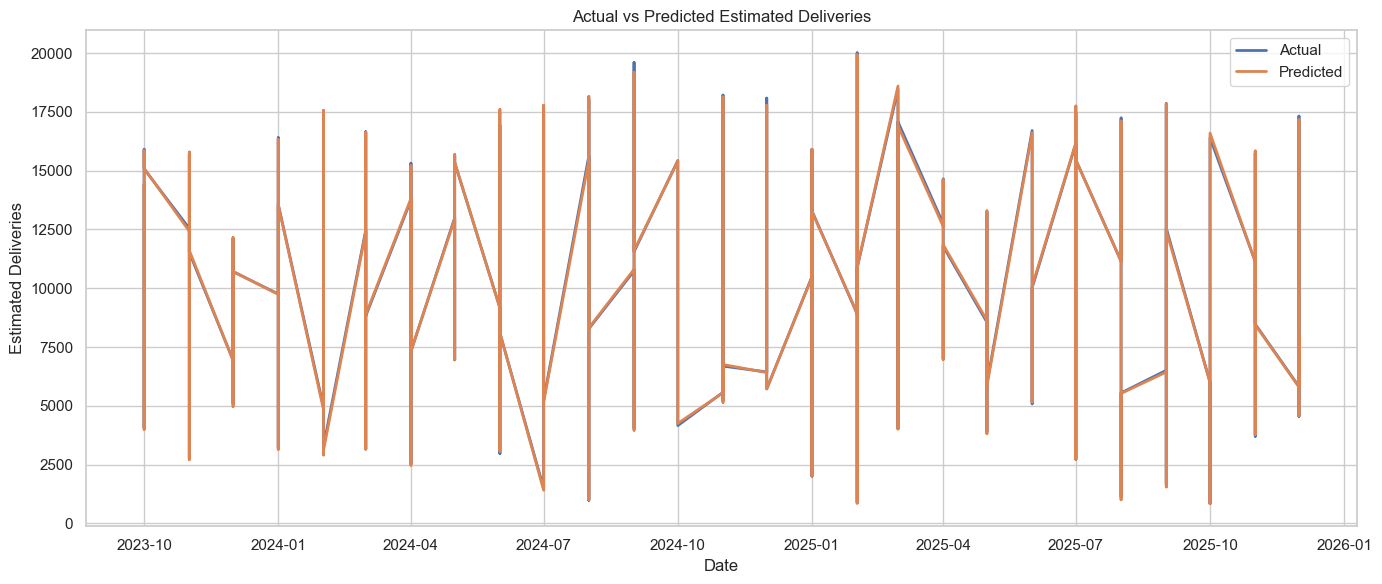

,Actual,Forecast
Date,,
2025-01-01,184411,219121.574545
2025-02-01,195061,190128.363631
2025-03-01,212368,198262.725087
2025-04-01,209709,194064.172519
2025-05-01,172377,210371.022415


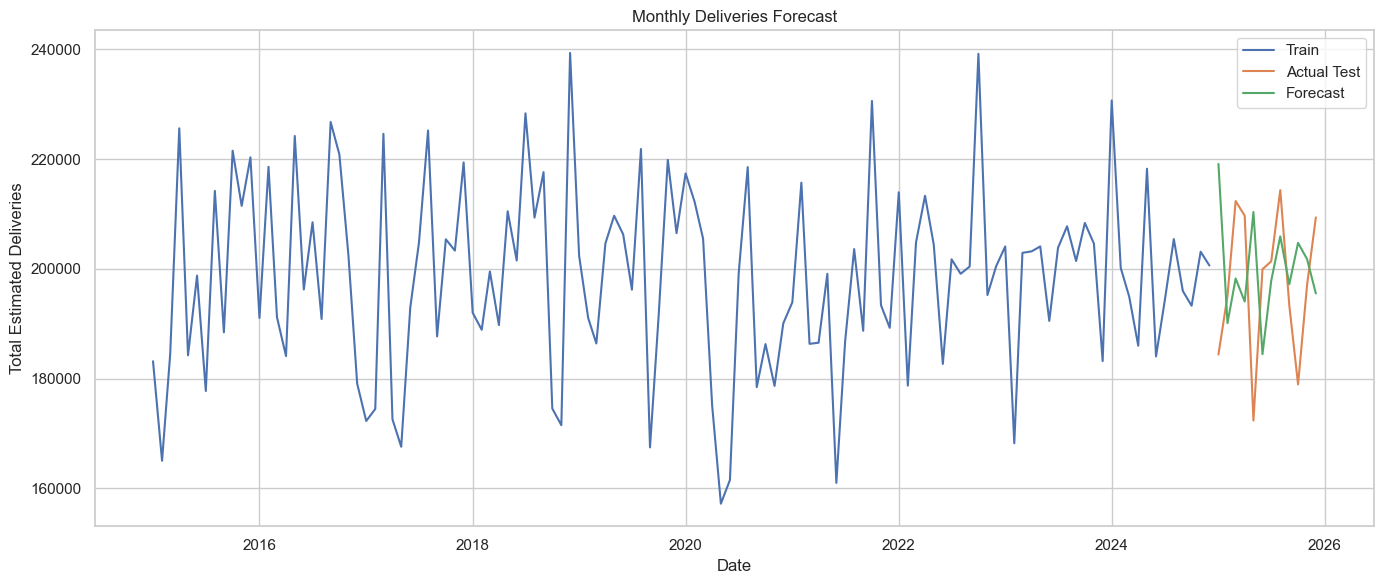

In [25]:
regression_predictions = final_model.predict(X_test_time)

prediction_frame = pd.DataFrame(
    {
        "Date": model_df.iloc[split_index:]["Date"].values,
        "Actual": y_test_time.values,
        "Predicted": regression_predictions,
    }
)

display(prediction_frame.head())

plt.figure(figsize=(14, 6))
plt.plot(prediction_frame["Date"], prediction_frame["Actual"], label="Actual", linewidth=2)
plt.plot(prediction_frame["Date"], prediction_frame["Predicted"], label="Predicted", linewidth=2)
plt.title("Actual vs Predicted Estimated Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

monthly_deliveries = model_df.groupby("Date")["Estimated_Deliveries"].sum().asfreq("MS")
monthly_deliveries = monthly_deliveries.interpolate(method="linear")
train_end = monthly_deliveries.index.max() - pd.DateOffset(months=12)
train_series = monthly_deliveries.loc[:train_end]
test_series = monthly_deliveries.loc[train_end + pd.DateOffset(months=1):]

sarimax_model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_results = sarimax_model.fit(disp=False)
forecast_steps = len(test_series)
forecast_results = sarimax_results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_results.predicted_mean
forecast_ci = forecast_results.conf_int()

forecast_frame = pd.DataFrame(
    {
        "Actual": test_series.values,
        "Forecast": forecast_mean.values,
    },
    index=test_series.index,
)

display(forecast_frame.head())

plt.figure(figsize=(14, 6))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Actual Test")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast")
plt.title("Monthly Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Total Estimated Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

,Task,MAE,MSE,RMSE,R2,MAPE_%
0,Regression,51.367718,5474.129862,73.987363,0.999594,0.636640
1,Forecast,15247.473083,NaN,19002.182932,NaN,8.024901


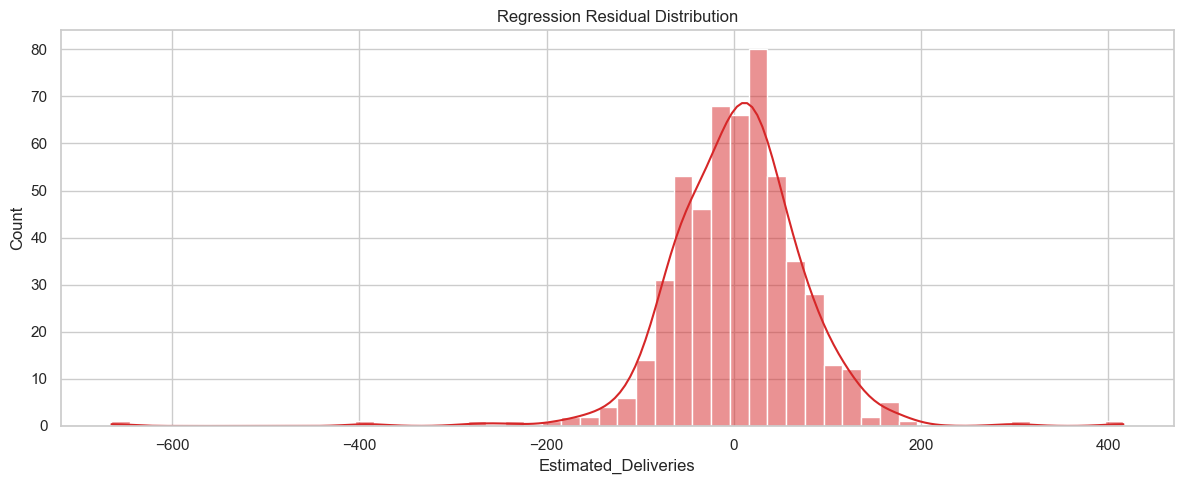

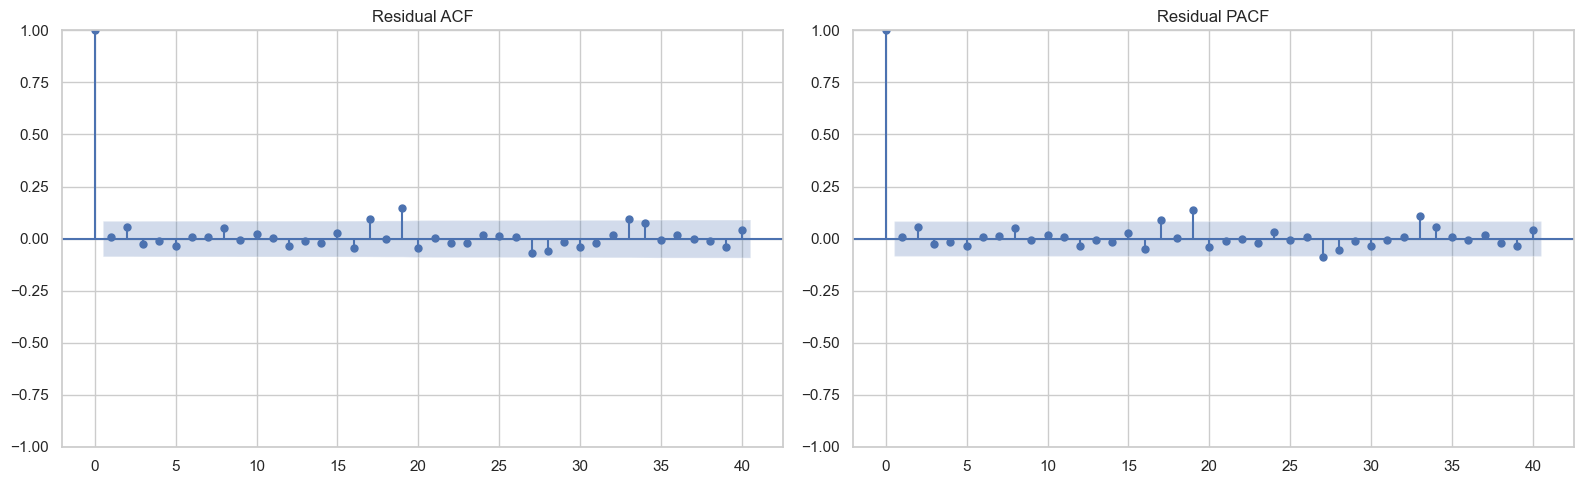

,Model,MAE,RMSE,R2
0,TunedFinalModel,51.367718,73.987363,0.999594
1,XGBRegressor,59.345631,83.623123,0.999482
2,RandomForestRegressor,66.050518,98.712614,0.999278
3,LinearRegression,106.508261,151.055949,0.998309


,Feature,Importance
6,numeric__Production_Units,0.974549
14,numeric__Production_to_Delivery,0.016302
28,categorical__Model_Model 3,0.001752
9,numeric__Range_km,0.001378
0,numeric__Year,0.001328
17,numeric__Delivery_to_Stations,0.000921
34,categorical__Source_Type_Official (Quarter),0.000753
10,numeric__CO2_Saved_tons,0.000685
12,numeric__Battery_to_Range,0.000435
18,numeric__Delivery_Lag_1,0.000342


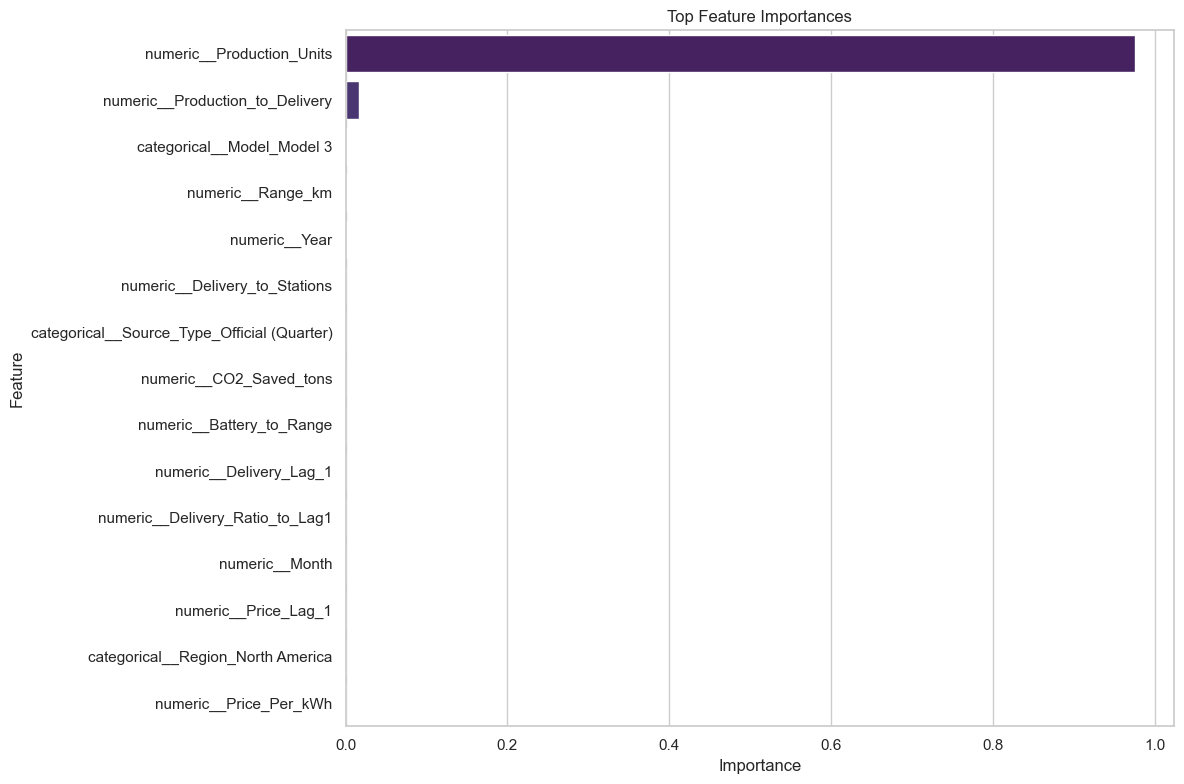

In [26]:
regression_mae = mean_absolute_error(y_test_time, regression_predictions)
regression_mse = float(np.mean((np.asarray(y_test_time) - np.asarray(regression_predictions)) ** 2))
regression_rmse = float(np.sqrt(regression_mse))
regression_r2 = r2_score(y_test_time, regression_predictions)
regression_mape = np.mean(np.abs((y_test_time - regression_predictions) / y_test_time)) * 100

forecast_mae = mean_absolute_error(test_series, forecast_mean)
forecast_rmse = float(np.sqrt(np.mean((np.asarray(test_series) - np.asarray(forecast_mean)) ** 2)))
forecast_mape = np.mean(np.abs((test_series - forecast_mean) / test_series)) * 100

metrics_table = pd.DataFrame(
    [
        {
            "Task": "Regression",
            "MAE": regression_mae,
            "MSE": regression_mse,
            "RMSE": regression_rmse,
            "R2": regression_r2,
            "MAPE_%": regression_mape,
        },
        {
            "Task": "Forecast",
            "MAE": forecast_mae,
            "MSE": np.nan,
            "RMSE": forecast_rmse,
            "R2": np.nan,
            "MAPE_%": forecast_mape,
        },
    ]
)

display(metrics_table)

residuals = y_test_time - regression_predictions
plt.figure(figsize=(12, 5))
sns.histplot(x=residuals, kde=True, color="#d62728")
plt.title("Regression Residual Distribution")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(residuals, ax=axes[0], lags=min(40, len(residuals) - 1))
axes[0].set_title("Residual ACF")
plot_pacf(residuals, ax=axes[1], lags=min(40, len(residuals) - 1), method="ywm")
axes[1].set_title("Residual PACF")
plt.tight_layout()
plt.show()

performance_compare = baseline_results.copy()
performance_compare = pd.concat(
    [
        performance_compare,
        pd.DataFrame(
            [
                {
                    "Model": "TunedFinalModel",
                    "MAE": regression_mae,
                    "RMSE": regression_rmse,
                    "R2": regression_r2,
                }
            ]
        ),
    ],
    ignore_index=True,
)
display(performance_compare.sort_values("RMSE").reset_index(drop=True))

final_tree_model = final_model.named_steps["model"]
if hasattr(final_tree_model, "feature_importances_"):
    feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
    importances = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": final_tree_model.feature_importances_,
        }
    ).sort_values("Importance", ascending=False)
    display(importances.head(20))
    plt.figure(figsize=(12, 8))
    sns.barplot(data=importances.head(15), x="Importance", y="Feature", palette="viridis")
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()

,Task,MAE,MSE,RMSE,R2,MAPE_%
0,Regression,51.367718,5474.129862,73.987363,0.999594,0.636640
1,Forecast,15247.473083,NaN,19002.182932,NaN,8.024901


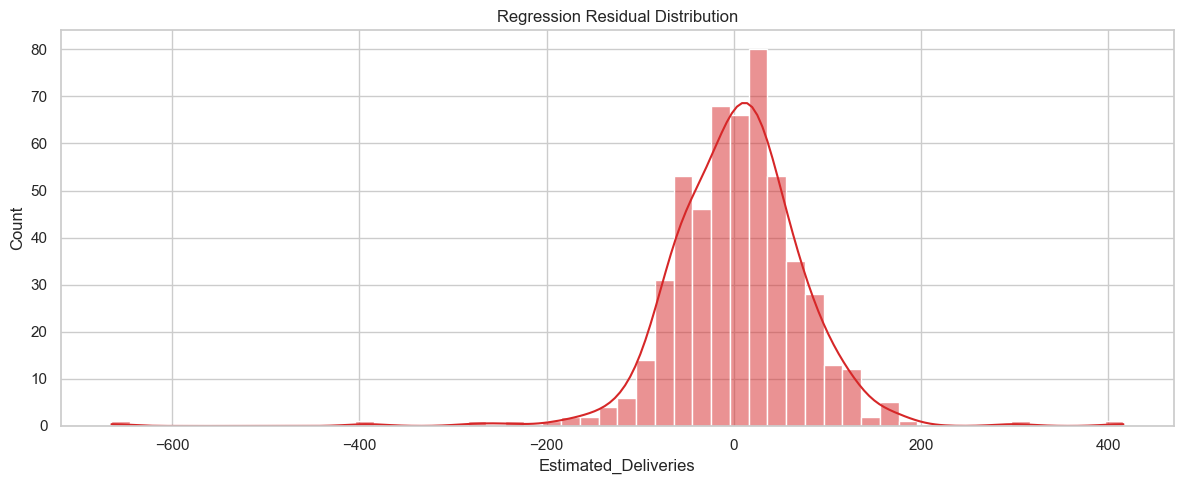

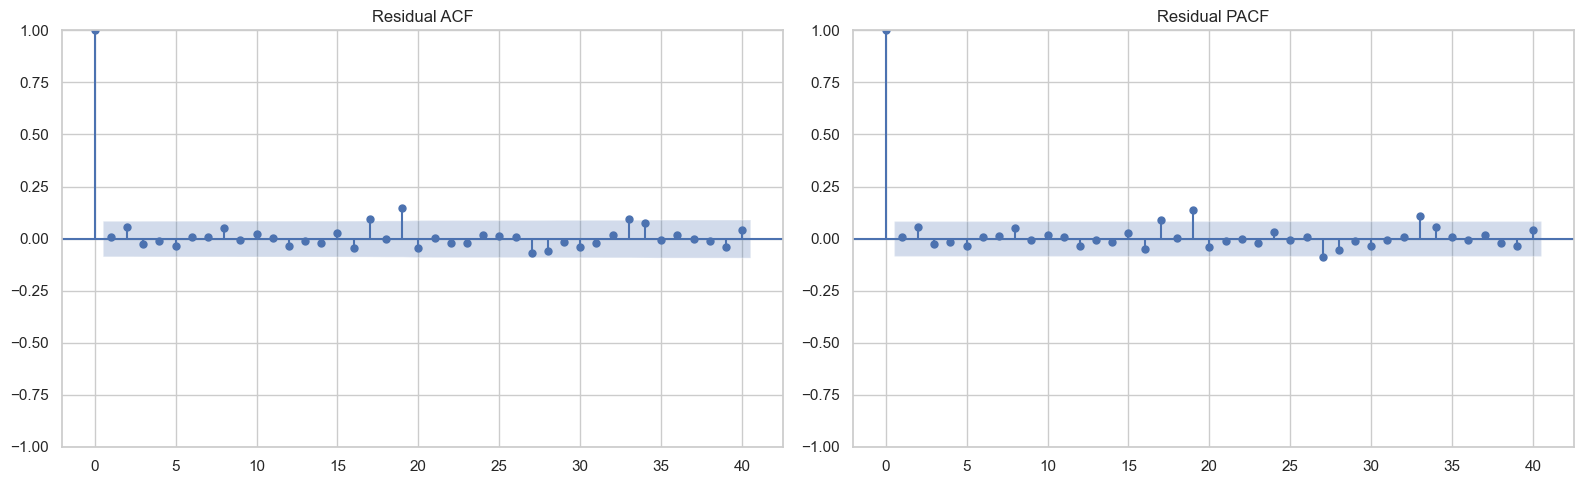

,Model,MAE,RMSE,R2
0,TunedFinalModel,51.367718,73.987363,0.999594
1,XGBRegressor,59.345631,83.623123,0.999482
2,RandomForestRegressor,66.050518,98.712614,0.999278
3,LinearRegression,106.508261,151.055949,0.998309


,Feature,Importance
6,numeric__Production_Units,0.974549
14,numeric__Production_to_Delivery,0.016302
28,categorical__Model_Model 3,0.001752
9,numeric__Range_km,0.001378
0,numeric__Year,0.001328
17,numeric__Delivery_to_Stations,0.000921
34,categorical__Source_Type_Official (Quarter),0.000753
10,numeric__CO2_Saved_tons,0.000685
12,numeric__Battery_to_Range,0.000435
18,numeric__Delivery_Lag_1,0.000342


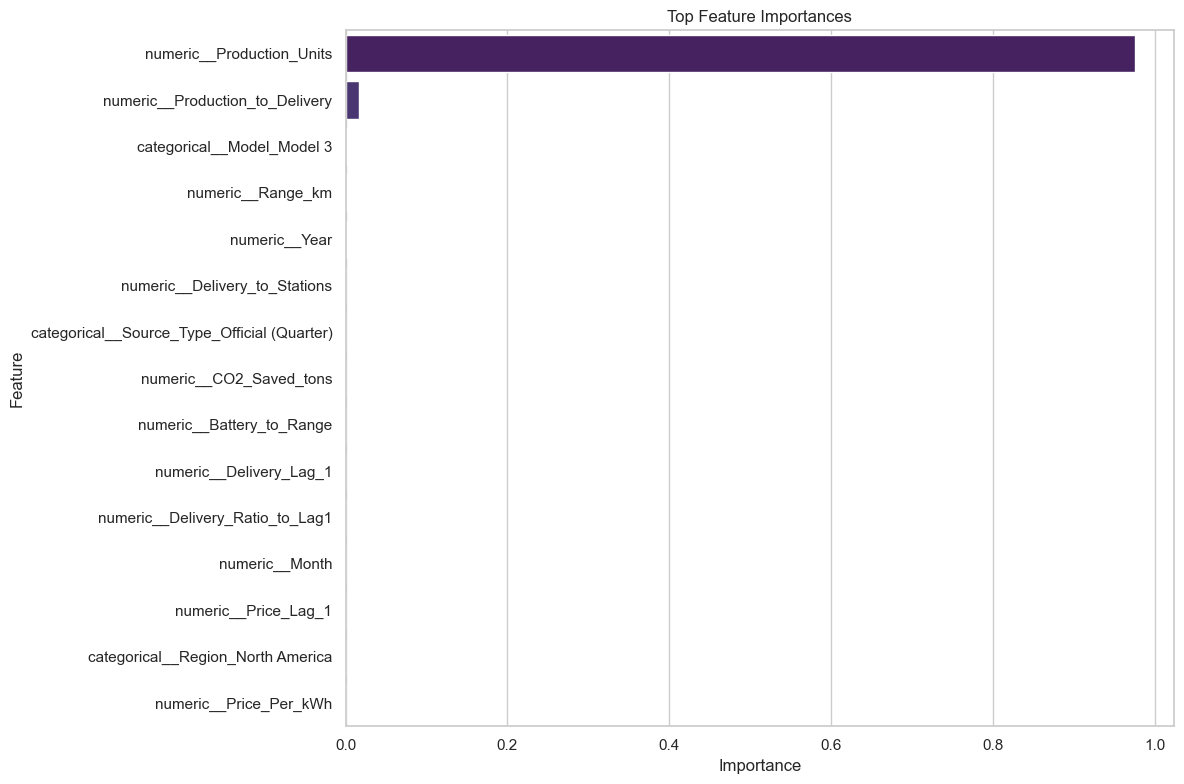

In [27]:
regression_mae = mean_absolute_error(y_test_time, regression_predictions)
regression_mse = float(np.mean((np.asarray(y_test_time) - np.asarray(regression_predictions)) ** 2))
regression_rmse = float(np.sqrt(regression_mse))
regression_r2 = r2_score(y_test_time, regression_predictions)
regression_mape = np.mean(np.abs((y_test_time - regression_predictions) / y_test_time)) * 100

forecast_mae = mean_absolute_error(test_series, forecast_mean)
forecast_rmse = float(np.sqrt(np.mean((np.asarray(test_series) - np.asarray(forecast_mean)) ** 2)))
forecast_mape = np.mean(np.abs((test_series - forecast_mean) / test_series)) * 100

metrics_table = pd.DataFrame(
    [
        {
            "Task": "Regression",
            "MAE": regression_mae,
            "MSE": regression_mse,
            "RMSE": regression_rmse,
            "R2": regression_r2,
            "MAPE_%": regression_mape,
        },
        {
            "Task": "Forecast",
            "MAE": forecast_mae,
            "MSE": np.nan,
            "RMSE": forecast_rmse,
            "R2": np.nan,
            "MAPE_%": forecast_mape,
        },
    ]
)

display(metrics_table)

residuals = y_test_time - regression_predictions
plt.figure(figsize=(12, 5))
sns.histplot(x=residuals, kde=True, color="#d62728")
plt.title("Regression Residual Distribution")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(residuals, ax=axes[0], lags=min(40, len(residuals) - 1))
axes[0].set_title("Residual ACF")
plot_pacf(residuals, ax=axes[1], lags=min(40, len(residuals) - 1), method="ywm")
axes[1].set_title("Residual PACF")
plt.tight_layout()
plt.show()

performance_compare = baseline_results.copy()
performance_compare = pd.concat(
    [
        performance_compare,
        pd.DataFrame(
            [
                {
                    "Model": "TunedFinalModel",
                    "MAE": regression_mae,
                    "RMSE": regression_rmse,
                    "R2": regression_r2,
                }
            ]
        ),
    ],
    ignore_index=True,
)
display(performance_compare.sort_values("RMSE").reset_index(drop=True))

final_tree_model = final_model.named_steps["model"]
if hasattr(final_tree_model, "feature_importances_"):
    feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
    importances = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": final_tree_model.feature_importances_,
        }
    ).sort_values("Importance", ascending=False)
    display(importances.head(20))
    plt.figure(figsize=(12, 8))
    sns.barplot(data=importances.head(15), x="Importance", y="Feature", palette="viridis")
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()

## Step 10: Saved Model

Persist the model artifacts and verify that they can be loaded back for inference.

In [28]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

preprocessor_path = MODEL_DIR / "preprocessor.pkl"
model_path = MODEL_DIR / "model.pkl"
metadata_path = MODEL_DIR / "metadata.json"

joblib.dump(final_model.named_steps["preprocessor"], preprocessor_path)
joblib.dump(final_model.named_steps["model"], model_path)

metadata = {
    "target": tabular_target,
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_rows": int(df.shape[0]),
    "train_rows": int(X_train_time.shape[0]),
    "test_rows": int(X_test_time.shape[0]),
    "best_model_class": final_model.named_steps["model"].__class__.__name__,
    "best_params": search.best_params_,
    "regression_metrics": {
        "mae": regression_mae,
        "mse": regression_mse,
        "rmse": regression_rmse,
        "r2": regression_r2,
        "mape_percent": regression_mape,
    },
    "forecast_metrics": {
        "mae": forecast_mae,
        "rmse": forecast_rmse,
        "mape_percent": forecast_mape,
    },
}

with open(metadata_path, "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2)

print(f"Saved preprocessor to {preprocessor_path}")
print(f"Saved model to {model_path}")
print(f"Saved metadata to {metadata_path}")

loaded_preprocessor = joblib.load(preprocessor_path)
loaded_model = joblib.load(model_path)
loaded_pipeline: Pipeline = Pipeline([
    ("preprocessor", loaded_preprocessor),
    ("model", loaded_model),
])

sample_predictions = loaded_pipeline.predict(X_test_time.head(3))
verification_frame = pd.DataFrame(
    {
        "Actual": y_test_time.head(3).values,
        "Predicted": sample_predictions,
    }
)
display(verification_frame)

Saved preprocessor to c:\Users\katur\OneDrive\Desktop\week2_celabal\models\preprocessor.pkl
Saved model to c:\Users\katur\OneDrive\Desktop\week2_celabal\models\model.pkl
Saved metadata to c:\Users\katur\OneDrive\Desktop\week2_celabal\models\metadata.json


,Actual,Predicted
0,14430,14386.172852
1,4070,3997.315430
2,15912,15857.445312
